In [37]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [38]:
PROCESSED_DATA = Path("../data/processed/")
FIGURES_PATH = Path("../reports/figures/")

In [39]:
df = pd.read_parquet(PROCESSED_DATA/ "users.parquet")

In [40]:
df.head()

,user_id,age,sex,education,primary_source_of_income,sum_of_monthly_installments,sum_of_monthly_expenses,country,signup_date,risk_score
0,U00001,56,Other,High School,Employment,477.69,243.18,Finland,2021-04-01,0.571079
1,U00002,36,Female,Bachelor,Business,31.60,737.76,France,2020-07-07,0.705268
2,U00003,70,Other,High School,Student Aid,275.72,1477.50,Finland,2022-08-23,0.429579
3,U00004,38,Other,High School,Savings,288.29,1135.03,Belgium,2022-05-21,0.581384
4,U00005,61,Male,High School,Employment,7.00,892.76,Italy,2022-03-15,0.420227


In [41]:
def dist_visualisation(
        data: np.ndarray | pd.Series | list,
        title: str = "",
        show: bool = True
) -> tuple[plt.Figure, dict[str, plt.Axes]] | None:
    """
    Visualize the distribution of data using boxplot, violinplot, and histogram.

    Args:
        data: Input numerical data to visualize.
        title: Title of the entire figure.
        show: If True, displays the plot. If False, returns the figure and axes.

    Returns:
        Tuple of matplotlib figure and axes dictionary if show=False, otherwise None.
    """
    fig = plt.figure(constrained_layout=True)
    plt.style.use('seaborn-v0_8')

    ax_dict = fig.subplot_mosaic([
        ['boxplot', 'violin'],
        ['histogram', 'violin'],
        ['histogram', 'violin'],
    ])

    mean_props = dict(color="darkorange", linestyle="dashed")

    ax_dict['boxplot'].boxplot(
        data,
        showmeans=True,
        meanline=True,
        meanprops=mean_props,
        vert=False
    )

    violin = ax_dict['violin'].violinplot(
        data,
        showmeans=True,
        showmedians=True
    )
    violin["cbars"].set_linestyle('dotted')

    ax_dict['histogram'].hist(data, bins='sqrt', color='orange')

    ax_dict['violin'].set_xlabel('KDE')
    ax_dict['histogram'].set_ylabel('Count Frequency')

    fig.suptitle(title)

    if not show:
        return fig, ax_dict

    plt.show()
    return None

In [42]:
import math

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def dist_categorical_visualisation(
        df: pd.DataFrame,
        categorical_cols: list[str],
        n_cols: int = 2,
        figsize: tuple | None = None,
        title: str | None = "Categorical Feature Distributions",
        save_path: str | None = None
) -> tuple[plt.Figure, dict[str, plt.Axes]] | None:
    """
    Plots count distributions for multiple categorical columns using subplots, in a clean and professional style.

    Args:
        df: DataFrame containing the data.
        categorical_cols: List of column names to visualize.
        n_cols: Number of columns in the subplot grid.
        figsize: Size of the entire figure. If None, inferred automatically.
        title: Title of the whole figure.
        save_path: If provided, saves the figure to this path instead of displaying it.
    """

    n = len(categorical_cols)
    n_rows = math.ceil(n / n_cols)
    figsize = figsize or (6 * n_cols, 4.5 * n_rows)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=figsize)
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(categorical_cols):
        ax = axes[i]
        sns.countplot(y=col, data=df, order=df[col].value_counts().index, ax=ax, color="steelblue", edgecolor="black")
        ax.set_title(f"Distribution of {col}", fontsize=13, weight="bold")
        ax.set_xlabel("Count", fontsize=11)
        ax.set_ylabel(col, fontsize=11)
        ax.tick_params(axis="y", labelsize=9)
        ax.tick_params(axis="x", labelsize=9)
        max_val = df[col].value_counts().max()
        ax.set_xlim(0, max_val * 1.1)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    if title:
        fig.suptitle(title, fontsize=16, weight="bold")
        fig.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        fig.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

    return fig, axes

In [43]:
print("Initial shape:", df.shape)

Initial shape: (20000, 10)


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      20000 non-null  object 
 1   age                          20000 non-null  int64  
 2   sex                          20000 non-null  object 
 3   education                    16138 non-null  object 
 4   primary_source_of_income     20000 non-null  object 
 5   sum_of_monthly_installments  20000 non-null  float64
 6   sum_of_monthly_expenses      20000 non-null  float64
 7   country                      20000 non-null  object 
 8   signup_date                  20000 non-null  object 
 9   risk_score                   20000 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 1.5+ MB


In [45]:
df["signup_date"] = pd.to_datetime(df["signup_date"])

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   user_id                      20000 non-null  object        
 1   age                          20000 non-null  int64         
 2   sex                          20000 non-null  object        
 3   education                    16138 non-null  object        
 4   primary_source_of_income     20000 non-null  object        
 5   sum_of_monthly_installments  20000 non-null  float64       
 6   sum_of_monthly_expenses      20000 non-null  float64       
 7   country                      20000 non-null  object        
 8   signup_date                  20000 non-null  datetime64[ns]
 9   risk_score                   20000 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 1.5+ MB


In [47]:
missing = df.isna().sum()
print("Explicit missing values: \n", missing[missing>0])

Explicit missing values: 
 education    3862
dtype: int64


### Categorical Data

In [48]:
categorical_cols = ["sex", "education", "primary_source_of_income", "country"]

In [49]:
df["education"].value_counts()

education
PhD            4162
Master         4019
Bachelor       4011
High School    3946
Name: count, dtype: int64

In [50]:
df.loc[df["education"].isna()]

,user_id,age,sex,education,primary_source_of_income,sum_of_monthly_installments,sum_of_monthly_expenses,country,signup_date,risk_score
5,U00006,33,Male,None,Savings,79.49,113.97,Poland,2021-06-28,0.482379
7,U00008,24,Other,None,Unemployment,56.09,80.72,Italy,2024-12-10,0.484288
8,U00009,21,Female,None,Retirement,855.24,994.18,Portugal,2021-01-16,0.478967
16,U00017,62,Female,None,Business,45.57,1944.58,Finland,2020-07-12,0.398462
23,U00024,43,Male,None,Student Aid,80.75,354.97,Italy,2022-09-02,0.619339
...,...,...,...,...,...,...,...,...,...,...
19978,U19979,37,Other,None,Retirement,22.04,94.51,Belgium,2024-11-15,0.558565
19983,U19984,22,Female,None,Unemployment,15.99,1776.45,Austria,2021-09-06,0.817778
19986,U19987,70,Other,None,Student Aid,440.07,2010.91,Italy,2020-12-06,0.392217
19997,U19998,53,Other,None,Unemployment,142.07,281.32,Austria,2022-05-31,0.411991


In [51]:
df["education"] = df["education"].fillna("Missing")

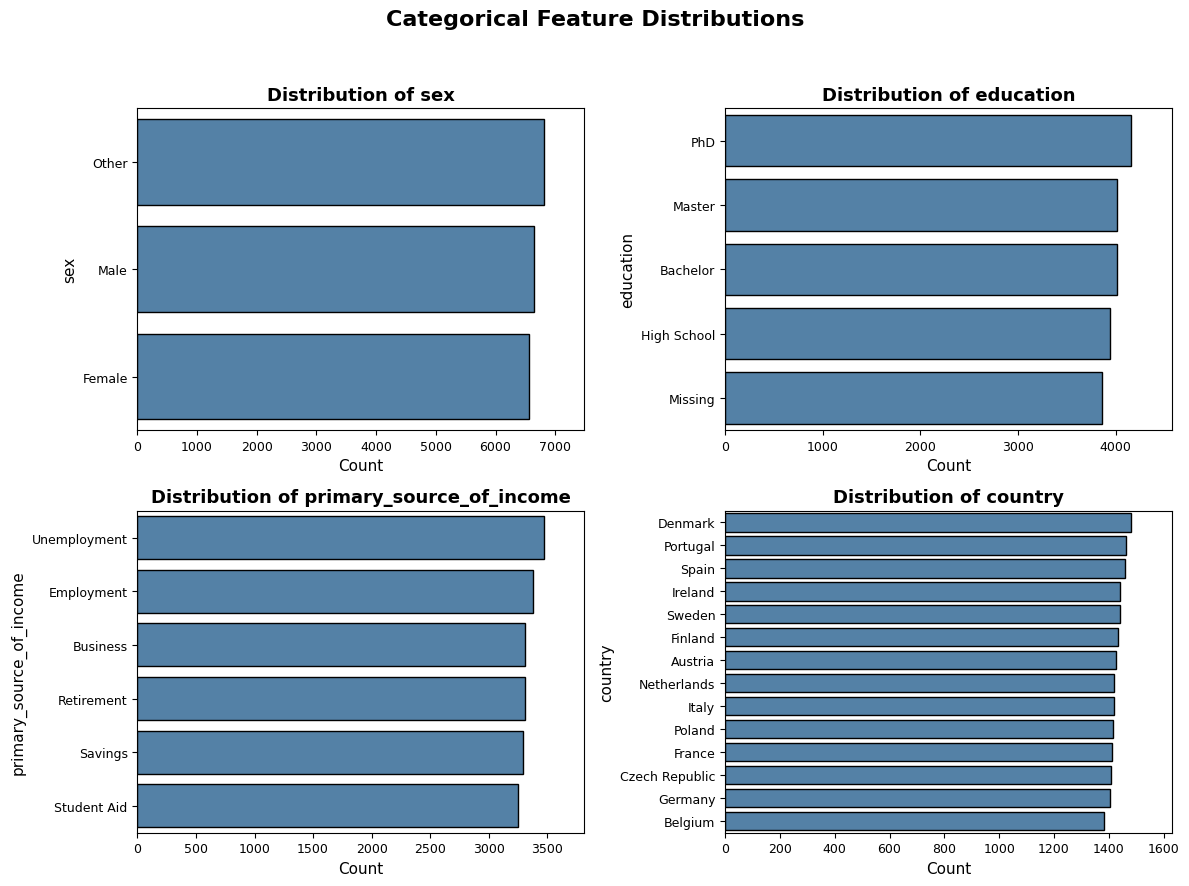

(<Figure size 1200x900 with 4 Axes>,
 array([<Axes: title={'center': 'Distribution of sex'}, xlabel='Count', ylabel='sex'>,
        <Axes: title={'center': 'Distribution of education'}, xlabel='Count', ylabel='education'>,
        <Axes: title={'center': 'Distribution of primary_source_of_income'}, xlabel='Count', ylabel='primary_source_of_income'>,
        <Axes: title={'center': 'Distribution of country'}, xlabel='Count', ylabel='country'>],
       dtype=object))

In [52]:
dist_categorical_visualisation(df,categorical_cols )

### Numerical Data

In [53]:
numerical_cols = df.select_dtypes(["number"])

In [54]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
age,20000.0,45.9733,18.0,32.0,46.0,60.0,74.0,16.520649
sum_of_monthly_installments,20000.0,301.669748,0.01,87.7675,207.65,418.2725,3165.7,304.160334
sum_of_monthly_expenses,20000.0,1184.221874,0.04,353.655,824.885,1651.9875,10994.33,1172.054772
signup_date,20000,2022-10-07 04:32:22.560000256,2020-04-21 00:00:00,2021-07-09 00:00:00,2022-10-08 00:00:00,2024-01-02 00:00:00,2025-03-22 00:00:00,NaN
risk_score,20000.0,0.501277,0.0,0.39848,0.500119,0.603234,1.0,0.149876


In [61]:
numerical_cols = ["age","sum_of_monthly_installments","sum_of_monthly_expenses","risk_score"]

TypeError: 'DataFrame' object is not callable

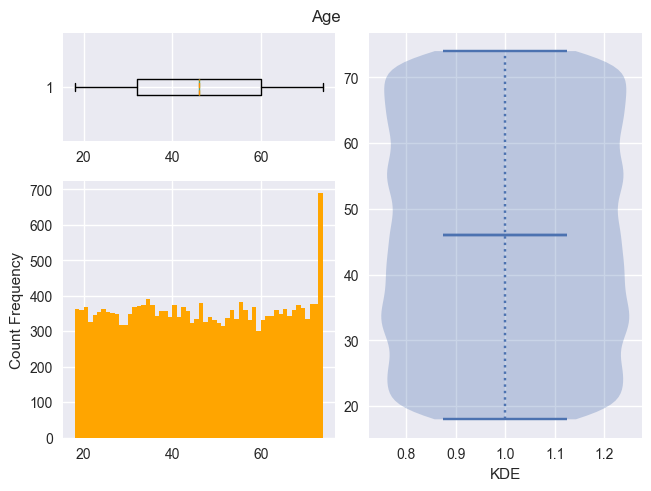

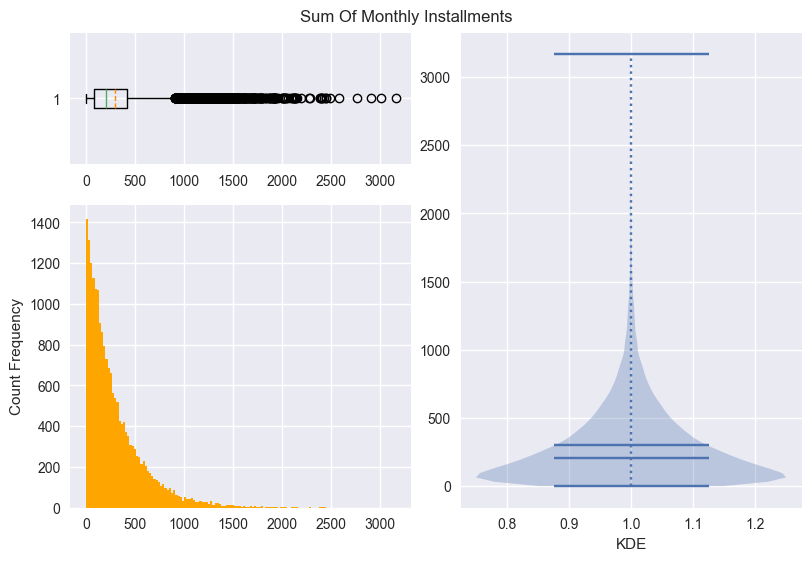

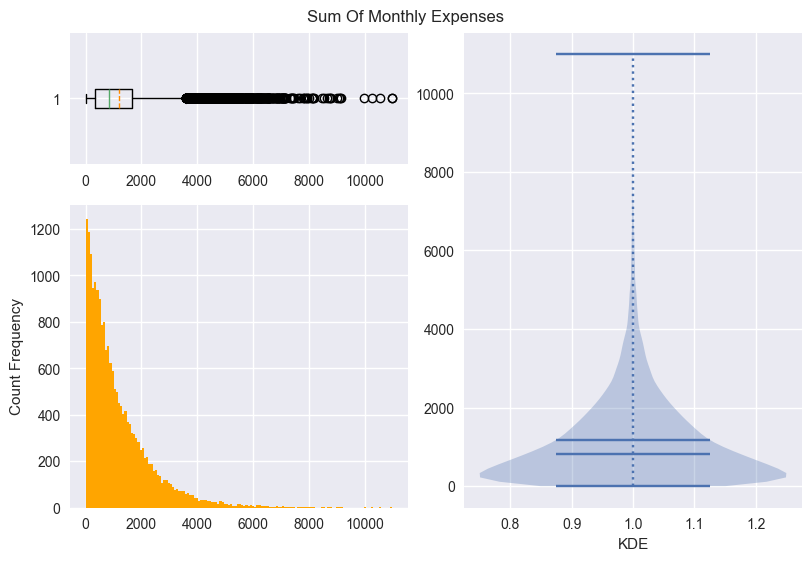

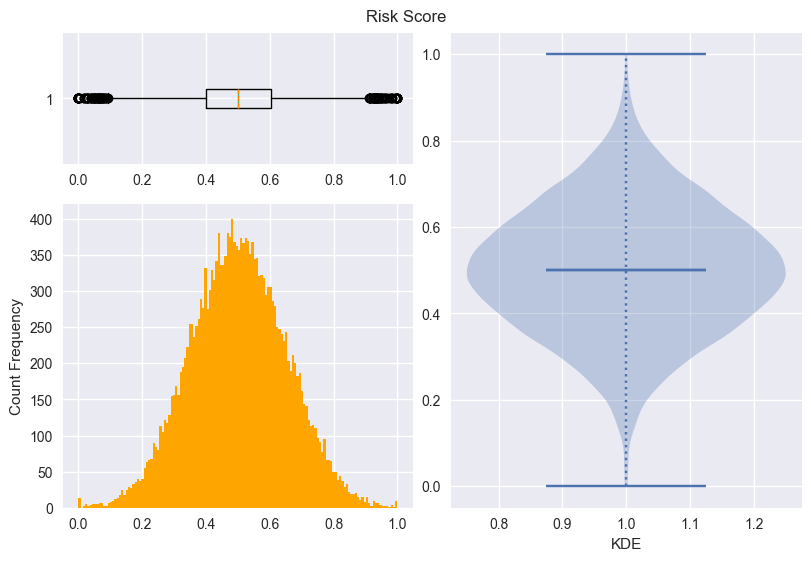

In [62]:
for col in numerical_cols:
    dist_visualisation(df[col], col.title().replace("_", " "))

In [63]:
corr= df[numerical_cols].corr()

In [64]:
corr

,age,sum_of_monthly_installments,sum_of_monthly_expenses,risk_score
age,1.000000,-0.012397,0.003306,0.007393
sum_of_monthly_installments,-0.012397,1.000000,0.011110,-0.002871
sum_of_monthly_expenses,0.003306,0.011110,1.000000,-0.000843
risk_score,0.007393,-0.002871,-0.000843,1.000000


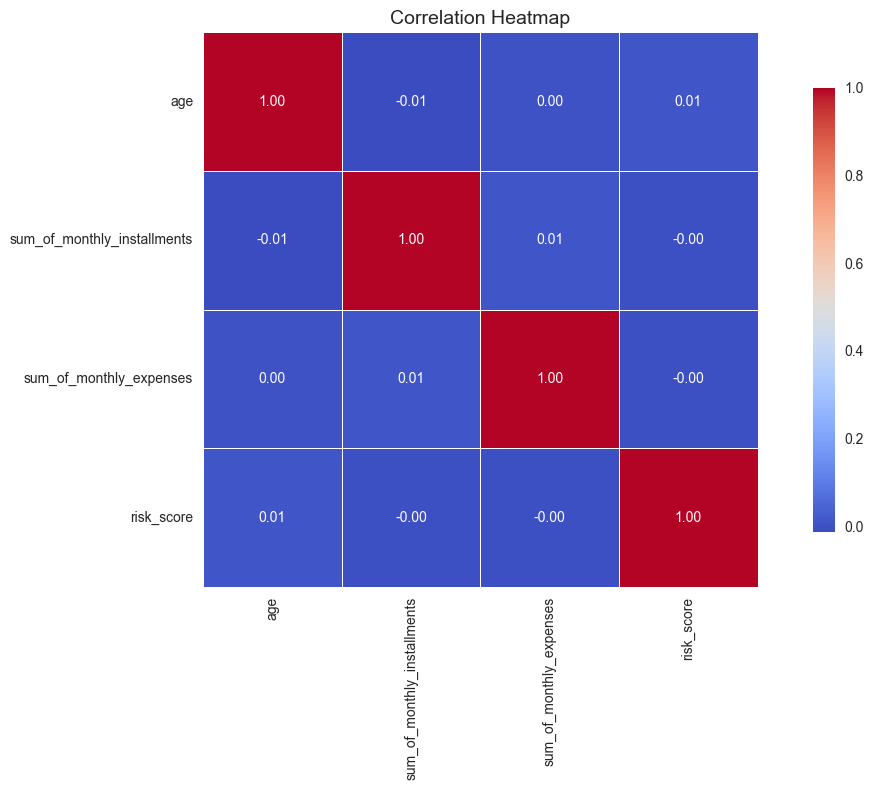

In [65]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    corr,
    ax=ax,
    annot=True,           # poprawka: powinno być 'annot' zamiast 'annotation'
    fmt='.2f',
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": 0.8},
    cmap="coolwarm",
)

ax.set_title("Correlation Heatmap", fontsize=14)
plt.tight_layout()       # poprawka: tight_layout, nie tight_lauout
plt.show()